- ReAct : ReAct stands for Reason + Act.
    - The actual internal cycle is Thought -> Action -> Observation
    - "ReAct is the framework of Reasoning and Acting. It implements this by following a cycle of Thought, Action, and Observation."
- Thought (Reasoning): The LLM "thinks" about the user's request and decides what to do next
- Action: The LLM chooses a tool to call (e.g., track_order).
- Observation: The LLM "observes" the output of that tool (the data returned from your function).

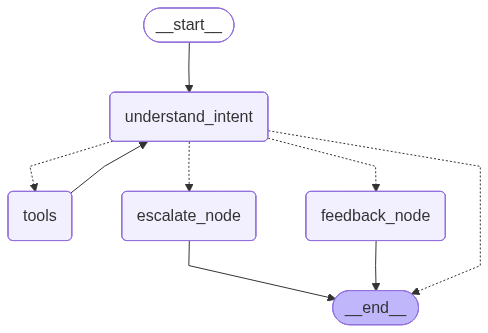


SCENARIO A: All issues resolvable

NODE: understand_intent | Attempt: 1
Messages in state so far: 1
LLM decision: ['track_order', 'get_product_info']

--- ROUTER | Attempt: 1 | next_action: escalate ---
→ Tools requested: ['track_order', 'get_product_info'] → TOOLS

NODE: understand_intent | Attempt: 2
Messages in state so far: 4
LLM decision: No tools — final response
LLM tagged: RESOLVED

--- ROUTER | Attempt: 2 | next_action: resolved ---
→ LLM confirmed RESOLVED → FEEDBACK

NODE: generate_feedback | Total messages: 5
Personalized feedback generated using full conversation history.

FINAL RESULTS
Attempts taken : 2
Issue resolved : True
Next action    : resolved
Total messages : 6

FINAL RESPONSE TO CUSTOMER

[Agent Response]
Of course! I've tracked your order and looked up the shoes for you.

Your order ORD-123 has been shipped and is scheduled to arrive tomorrow by 8 PM via FedEx. I can also confirm that the Nike Shoes are available in red.

[Feedback Request]
I'm so glad I could

In [6]:
"""
E-Commerce Customer Support Agent
==================================
Use Case:
    A real-world multi-tool AI agent that handles customer support queries
    for an e-commerce platform. A customer can ask multiple questions in one
    message (e.g., track an order, request a refund, check product availability)
    and the agent resolves ALL of them in a single conversation flow.

Architecture:
    - LangGraph orchestrates the flow as a stateful graph
    - LLM (Gemini via Vertex AI) decides which tools to call — no hardcoding
    - Reducer (add_messages) accumulates the full conversation history
    - Tools execute real business logic (order tracking, refunds, etc.)
    - LLM explicitly tags [STATUS: RESOLVED] or [STATUS: ESCALATE]
    - Feedback collected only when LLM confirms resolution
    - Escalation triggered when LLM cannot resolve the issue

Graph Flow:
    START
      └─► understand_intent  (LLM decides tools to call + sets status tag)
               ├─► tools         (executes chosen tools)
               │     └─► understand_intent  (loop back — LLM reads results)
               ├─► feedback_node (LLM tagged RESOLVED)
               └─► escalate_node (LLM tagged ESCALATE or max attempts)
                         └─► END
"""

import os
from typing import Annotated, Literal
from typing_extensions import TypedDict
from langchain_google_vertexai import ChatVertexAI
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage, SystemMessage
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode
from dotenv import load_dotenv

load_dotenv()


# ─────────────────────────────────────────
# 1. TOOLS — Business Logic
# ─────────────────────────────────────────

def track_order(order_id: str) -> str:
    """
    Track the current shipping status and ETA of a customer's order.

    Args:
        order_id: The unique order identifier (e.g., 'ORD-123')

    Returns:
        A formatted string with item name, shipping status,
        estimated arrival time, and carrier details.
        Returns an error message if the order ID is not found.

    Example:
        >>> track_order("ORD-123")
        "Order ORD-123 | Item: Nike Shoes | Status: Shipped | ETA: Tomorrow by 8 PM | Carrier: FedEx"
    """
    orders_db = {
        "ORD-123": {"status": "Shipped",    "eta": "Tomorrow by 8 PM",         "carrier": "FedEx", "item": "Nike Shoes"},
        "ORD-456": {"status": "Processing", "eta": "3-5 business days",         "carrier": "UPS",   "item": "Samsung TV"},
        "ORD-789": {"status": "Delivered",  "eta": "Delivered on Dec 10",       "carrier": "DHL",   "item": "Apple Watch"},
        "ORD-999": {"status": "Delayed",    "eta": "Unknown - warehouse issue", "carrier": "FedEx", "item": "Laptop"},
    }
    order = orders_db.get(order_id)
    if not order:
        return f"Order {order_id} not found. Please check your order ID."
    return (
        f"Order {order_id} | Item: {order['item']} | "
        f"Status: {order['status']} | ETA: {order['eta']} | "
        f"Carrier: {order['carrier']}"
    )


def check_return_eligibility(order_id: str) -> str:
    """
    Check whether a customer's order qualifies for a return or exchange
    based on the 30-day return policy.

    Args:
        order_id: The unique order identifier (e.g., 'ORD-789')

    Returns:
        A formatted string with return eligibility status, the reason
        (e.g., within window / expired), and days remaining for return.
        Returns an error message if the order ID is not found.

    Example:
        >>> check_return_eligibility("ORD-789")
        "Return Status: NOT ELIGIBLE | Reason: Return window expired | Days remaining: 0 days"
    """
    return_policy_db = {
        "ORD-123": {"eligible": True,  "reason": "Within 30-day return window",                   "days_left": 22},
        "ORD-456": {"eligible": True,  "reason": "Within 30-day return window",                   "days_left": 28},
        "ORD-789": {"eligible": False, "reason": "Return window expired (delivered 45 days ago)", "days_left": 0},
        "ORD-999": {"eligible": True,  "reason": "Eligible due to delay compensation policy",     "days_left": 30},
    }
    policy = return_policy_db.get(order_id)
    if not policy:
        return f"Cannot find return policy for order {order_id}."
    status = "ELIGIBLE" if policy["eligible"] else "NOT ELIGIBLE"
    return (
        f"Return Status: {status} | "
        f"Reason: {policy['reason']} | "
        f"Days remaining: {policy['days_left']} days"
    )


def process_refund(order_id: str, reason: str) -> str:
    """
    Initiate a refund for a customer's eligible order.

    Args:
        order_id: The unique order identifier (e.g., 'ORD-123')
        reason:   The customer-provided reason for requesting the refund

    Returns:
        A formatted string confirming refund initiation with item name,
        refund amount, payment method, reason, and expected processing time.
        Returns an error message if the order is not found or not refund-eligible.

    Example:
        >>> process_refund("ORD-123", "Wrong size delivered")
        "Refund INITIATED | Order: ORD-123 | Item: Nike Shoes | Amount: $129.99 | ..."
    """
    refund_db = {
        "ORD-123": {"amount": 129.99,  "method": "Original Credit Card",               "item": "Nike Shoes"},
        "ORD-456": {"amount": 899.99,  "method": "Original Credit Card",               "item": "Samsung TV"},
        "ORD-999": {"amount": 1299.99, "method": "Original Credit Card + $50 voucher", "item": "Laptop"},
    }
    refund = refund_db.get(order_id)
    if not refund:
        return f"Cannot process refund for {order_id}. Order not found or not eligible."
    return (
        f"Refund INITIATED | Order: {order_id} | "
        f"Item: {refund['item']} | Amount: ${refund['amount']} | "
        f"Refund to: {refund['method']} | "
        f"Reason: {reason} | Processing time: 3-5 business days"
    )


def get_product_info(product_name: str) -> str:
    """
    Retrieve detailed product information including price, stock status,
    ratings, available sizes, and color options.

    Args:
        product_name: The name of the product to look up (case-insensitive).
                      E.g., 'Nike Shoes', 'Samsung TV'

    Returns:
        A formatted string with full product details.
        Returns an error message if the product is not found in the catalog.

    Example:
        >>> get_product_info("Nike Shoes")
        "Product: Nike Shoes | Price: $129.99 | Stock: In Stock | Rating: 4.5/5 | Sizes: 6-12 | Colors: Black, White, Red"
    """
    products_db = {
        "nike shoes":  {"price": 129.99,  "stock": "In Stock",      "rating": 4.5, "sizes": "6-12",  "colors": "Black, White, Red"},
        "samsung tv":  {"price": 899.99,  "stock": "Limited Stock", "rating": 4.7, "sizes": '55"',   "colors": "Black"},
        "apple watch": {"price": 399.99,  "stock": "In Stock",      "rating": 4.8, "sizes": "S/M/L", "colors": "Silver, Gold, Space Gray"},
        "laptop":      {"price": 1299.99, "stock": "Out of Stock",  "rating": 4.3, "sizes": '15.6"', "colors": "Silver"},
    }
    product = products_db.get(product_name.lower())
    if not product:
        return f"Product '{product_name}' not found in our catalog."
    return (
        f"Product: {product_name} | Price: ${product['price']} | "
        f"Stock: {product['stock']} | Rating: {product['rating']}/5 | "
        f"Sizes: {product['sizes']} | Colors: {product['colors']}"
    )


tools = [track_order, check_return_eligibility, process_refund, get_product_info]


# ─────────────────────────────────────────
# 2. LLM SETUP
# ─────────────────────────────────────────

llm = ChatVertexAI(
    model="gemini-2.5-pro",
    project=os.getenv("GCP_PROJECT_ID"),
    location="us-central1",
    temperature=0
)

# Bind tools so the LLM can decide which ones to call
llm_with_tools = llm.bind_tools(tools)


# ─────────────────────────────────────────
# 3. STATE
# ─────────────────────────────────────────

class EcommerceState(TypedDict):
    """
    The shared state object passed between all nodes in the graph.

    Fields:
        messages:    Full conversation history. The `add_messages` reducer
                     APPENDS new messages instead of overwriting — this
                     preserves the entire conversation across all nodes
                     and loop iterations.

        resolved:    Flag indicating whether the customer's issue has been
                     fully resolved. Set to True by generate_feedback node
                     on success, remains False on escalation.

        feedback:    The personalized feedback message generated for the
                     customer after successful resolution. Empty string
                     until the feedback node runs.

        attempt:     Counts how many times understand_intent has run.
                     Used by the router to trigger escalation after 3
                     failed attempts. Incremented on every loop.

        next_action: Set by the LLM explicitly after reading tool results.
                     Value is either "resolved" or "escalate".
                     This drives the router decision — not guesswork.
    """
    messages:    Annotated[list[BaseMessage], add_messages]
    resolved:    bool
    feedback:    str
    attempt:     int
    next_action: str   # "resolved" | "escalate" — LLM sets this explicitly


# ─────────────────────────────────────────
# 4. NODES
# ─────────────────────────────────────────

def understand_intent(state: EcommerceState) -> dict:
    """
    Node 1 — Core reasoning node. The LLM reads the full conversation
    history, calls tools if needed, and after reading tool results
    explicitly tags the response with [STATUS: RESOLVED] or
    [STATUS: ESCALATE] so the router knows exactly where to go next.

    This node is the brain of the agent:
    - On first run  : reads customer message, picks tools to call
    - On second run : reads tool results, generates final response
                      with explicit STATUS tag

    The LLM makes ALL decisions — no keyword matching or hardcoded
    routing logic anywhere.

    Args:
        state: Current graph state containing full message history

    Returns:
        dict with updated messages (LLM response appended by reducer),
        incremented attempt counter, and next_action set by LLM tag
    """
    print(f"\n{'='*60}")
    print(f"NODE: understand_intent | Attempt: {state['attempt'] + 1}")
    print(f"Messages in state so far: {len(state['messages'])}")

    response = llm_with_tools.invoke([
        SystemMessage(content="""You are an expert e-commerce customer support agent.

        Your job:
        1. Carefully read the customer query
        2. Identify ALL issues they have mentioned
        3. Call ALL relevant tools to resolve every issue in parallel
        4. After reading tool results, give a clear final response

        Available tools:
        - track_order             : order status, location, ETA
        - check_return_eligibility: whether an order can be returned
        - process_refund          : initiate a refund for eligible orders
        - get_product_info        : product price, stock, colors, sizes

        RESOLUTION RULES — be strict:
        - Order ID not found in system          → ESCALATE
        - Return window expired / NOT ELIGIBLE  → ESCALATE
        - Refund cannot be processed            → ESCALATE
        - Product not found in catalog          → ESCALATE
        - ALL issues successfully resolved      → RESOLVED

        IMPORTANT: At the very end of your final response (NOT when calling tools),
        always add exactly one of these tags on a new line:
        [STATUS: RESOLVED]
        [STATUS: ESCALATE]
        """),
        *state["messages"]   # full history — reducer kept everything
    ])

    print(f"LLM decision: {[t['name'] for t in response.tool_calls] if response.tool_calls else 'No tools — final response'}")

    # Parse the STATUS tag from LLM response
    # Only do this when LLM gives final text response (not tool calls)
    next_action = state.get("next_action", "escalate")  # default safe fallback
    if not response.tool_calls and response.content:
        if "[STATUS: RESOLVED]" in response.content:
            next_action = "resolved"
            print("LLM tagged: RESOLVED")
        elif "[STATUS: ESCALATE]" in response.content:
            next_action = "escalate"
            print("LLM tagged: ESCALATE")

    return {
        "messages":    [response],          # reducer APPENDS, never overwrites
        "attempt":     state["attempt"] + 1,
        "next_action": next_action
    }


def generate_feedback(state: EcommerceState) -> dict:
    """
    Node 2 — Feedback collection node. Runs ONLY when LLM tagged
    [STATUS: RESOLVED], meaning ALL customer issues were successfully
    handled. Uses the complete conversation history to craft a warm,
    personalized feedback request referencing the exact issues resolved.

    Args:
        state: Current graph state with full conversation history

    Returns:
        dict with feedback message appended to messages, the feedback
        string stored separately, and resolved flag set to True
    """
    print(f"\n{'='*60}")
    print(f"NODE: generate_feedback | Total messages: {len(state['messages'])}")

    # Extract original customer query from the very first message
    original_query = state["messages"][0].content

    feedback_response = llm.invoke(
        state["messages"] +
        [HumanMessage(content=f"""Based on our entire conversation above,
        the customer originally asked: "{original_query}"
        We resolved their issue in {state['attempt']} attempt(s).

        Now write a SHORT, warm, personalized feedback request:
        - Reference the SPECIFIC issues we successfully resolved
        - Ask them to rate their experience from 1 to 5 stars
        - Keep it under 3 sentences
        - Be genuine and empathetic
        - Do NOT include any [STATUS:] tags in this message""")]
    )

    print("Personalized feedback generated using full conversation history.")

    return {
        "messages": [feedback_response],
        "feedback": feedback_response.content,
        "resolved": True
    }


def escalate_to_human(state: EcommerceState) -> dict:
    """
    Node 3 — Escalation node. Triggered when:
        (a) LLM tagged [STATUS: ESCALATE] — could not resolve the issue
        (b) attempt >= 3 — max retries reached
        (c) Unexpected state — safe fallback

    The LLM summarizes the entire conversation into a structured
    handoff brief for a human agent — what was tried, what failed,
    and what the customer still needs.

    Because the reducer preserved every message, the human agent
    receives complete context — nothing is lost.

    Args:
        state: Current graph state with full conversation history

    Returns:
        dict with escalation summary appended to messages, resolved set
        to False, and a feedback string indicating escalation occurred
    """
    print(f"\n{'='*60}")
    print(f"NODE: escalate_to_human | Messages preserved: {len(state['messages'])}")

    original_query = state["messages"][0].content

    summary_response = llm.invoke(
        state["messages"] +
        [HumanMessage(content=f"""Summarize this customer support conversation
        for a human agent takeover. Be concise and clear.

        Original query : {original_query}
        Attempts made  : {state['attempt']}

        Provide:
        1. What the customer needs
        2. What tools were already called and their results
        3. What could NOT be resolved and why
        4. Recommended next action for the human agent""")]
    )

    escalation_msg = AIMessage(content=(
        f"ESCALATED TO HUMAN AGENT\n"
        f"Attempts made: {state['attempt']}\n\n"
        f"Handoff summary:\n{summary_response.content}"
    ))

    return {
        "messages": [escalation_msg],
        "resolved": False,
        "feedback": "Escalated to human agent — no feedback collected"
    }


# ─────────────────────────────────────────
# 5. ROUTER
# ─────────────────────────────────────────

def router(state: EcommerceState) -> Literal["tools", "feedback_node", "escalate_node"]:
    """
    Conditional edge that decides the next node after understand_intent.

    Priority order:
    1. attempt >= 3 and unresolved  → escalate_node (prevent infinite loop)
    2. LLM wants tool_calls         → tools          (go execute tools)
    3. next_action == "resolved"    → feedback_node  (LLM confirmed success)
    4. next_action == "escalate"    → escalate_node  (LLM confirmed failure)
    5. Fallback                     → escalate_node  (safe default)

    The key fix: routing is driven by next_action (set by LLM STATUS tag),
    NOT by simply checking if last_msg.content exists. This ensures
    "order not found" correctly escalates instead of going to feedback.

    Args:
        state: Current graph state

    Returns:
        Name of the next node to execute
    """
    last_msg    = state["messages"][-1]
    attempt     = state["attempt"]
    next_action = state.get("next_action", "escalate")

    print(f"\n--- ROUTER | Attempt: {attempt} | next_action: {next_action} ---")

    # Safety valve — prevent infinite loops
    if attempt >= 3 and not state["resolved"]:
        print("→ Max attempts reached → ESCALATE")
        return "escalate_node"

    # LLM wants to call tools — go execute them
    if hasattr(last_msg, "tool_calls") and last_msg.tool_calls:
        print(f"→ Tools requested: {[t['name'] for t in last_msg.tool_calls]} → TOOLS")
        return "tools"

    # LLM explicitly confirmed resolution → collect feedback
    if next_action == "resolved":
        print("→ LLM confirmed RESOLVED → FEEDBACK")
        return "feedback_node"

    # LLM explicitly flagged escalation OR fallback
    print("→ LLM confirmed ESCALATE → ESCALATE")
    return "escalate_node"


# ─────────────────────────────────────────
# 6. BUILD GRAPH
# ─────────────────────────────────────────

builder = StateGraph(EcommerceState)

builder.add_node("understand_intent", understand_intent)
builder.add_node("tools",             ToolNode(tools))
builder.add_node("feedback_node",     generate_feedback)
builder.add_node("escalate_node",     escalate_to_human)

builder.add_edge(START,               "understand_intent")
builder.add_conditional_edges(
    "understand_intent",
    router,
    {
        "tools":         "tools",
        "feedback_node": "feedback_node",
        "escalate_node": "escalate_node"
    }
)
builder.add_edge("tools",         "understand_intent")  # loop: tool results → LLM
builder.add_edge("feedback_node", END)
builder.add_edge("escalate_node", END)

graph = builder.compile()

# Display graph (works in Jupyter; silently skipped in plain Python)
try:
    from IPython.display import Image, display
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass


# ─────────────────────────────────────────
# 7. PUBLIC API
# ─────────────────────────────────────────

def handle_customer_query(user_message: str) -> dict:
    """
    The single public entry point for the customer support agent.
    Caller only passes the customer's raw message — all internal
    state is initialized here and managed entirely by the graph.

    Args:
        user_message: The customer's natural language query.
                      Can contain multiple issues in one message.

    Returns:
        dict with keys:
            - feedback     (str):  Feedback request if resolved,
                                   escalation note if handed to human
            - resolved     (bool): True if issue resolved, False if escalated
            - attempt      (int):  Number of reasoning attempts made
            - next_action  (str):  Final LLM decision: "resolved" or "escalate"
            - messages     (list): Full conversation history for audit/logging
    """
    initial_state = {
        "messages":    [HumanMessage(content=user_message)],
        "resolved":    False,
        "feedback":    "",
        "attempt":     0,
        "next_action": "escalate"   # safe default — LLM will override this
    }
    return graph.invoke(initial_state)


# ─────────────────────────────────────────
# 8. DISPLAY HELPER
# ─────────────────────────────────────────

def display_result(result: dict):
    """
    Pretty-prints the full result from handle_customer_query().
    Shows summary stats, final response, feedback or escalation,
    and the complete message-by-message conversation history.

    Args:
        result: The dict returned by handle_customer_query()
    """
    print("\n" + "="*60)
    print("FINAL RESULTS")
    print("="*60)
    print(f"Attempts taken : {result['attempt']}")
    print(f"Issue resolved : {result['resolved']}")
    print(f"Next action    : {result['next_action']}")
    print(f"Total messages : {len(result['messages'])}")

    print("\n" + "="*60)
    print("FINAL RESPONSE TO CUSTOMER")
    print("="*60)

    if result["resolved"]:
        # Happy path: second-to-last = agent response, last = feedback
        agent_response = result["messages"][-2].content
        # Strip the [STATUS: RESOLVED] tag — customer doesn't need to see it
        agent_response = agent_response.replace("[STATUS: RESOLVED]", "").strip()
        feedback_msg   = result["messages"][-1].content
        print(f"\n[Agent Response]\n{agent_response}")
        print(f"\n[Feedback Request]\n{feedback_msg}")
    else:
        # Escalation path: last message is the escalation summary
        escalation_msg = result["messages"][-1].content
        print(f"\n[Escalated to Human Agent]\n{escalation_msg}")

    print("\n" + "="*60)
    print(f"FULL CONVERSATION HISTORY ({len(result['messages'])} messages)")
    print("="*60)

    for i, msg in enumerate(result["messages"]):
        msg_type = type(msg).__name__
        print(f"\n[{i+1}] {msg_type}")
        print("-" * 40)

        # AIMessage with tool_calls but no text — LLM tool decision
        if hasattr(msg, "tool_calls") and msg.tool_calls and not msg.content:
            print("  [Tool Call Decision — no text content]")
            for tc in msg.tool_calls:
                print(f"  → Calling tool : {tc['name']}")
                print(f"    With args    : {tc['args']}")

        # ToolMessage — result returned by an executed tool
        elif msg_type == "ToolMessage":
            tool_name = getattr(msg, "name", "unknown_tool")
            print(f"  Tool   : {tool_name}")
            print(f"  Result : {msg.content}")

        # HumanMessage or AIMessage with text content
        else:
            # Clean STATUS tags from display
            content = msg.content
            if isinstance(content, str):
                content = content.replace("[STATUS: RESOLVED]", "").replace("[STATUS: ESCALATE]", "").strip()
            print(f"  {content}")


# ─────────────────────────────────────────
# 9. RUN — Test all 3 scenarios
# ─────────────────────────────────────────

if __name__ == "__main__":

    # ── Scenario A: Happy path — all issues resolved ──
    print("\n" + "="*60)
    print("SCENARIO A: All issues resolvable")
    print("="*60)
    result_a = handle_customer_query(
        "Hi! Can you track my order ORD-123? "
        "And are Nike Shoes available in red color?"
    )
    display_result(result_a)

    # ── Scenario B: Invalid order ID — should ESCALATE ──
    print("\n" + "="*60)
    print("SCENARIO B: Invalid order ID — expect ESCALATION")
    print("="*60)
    result_b = handle_customer_query(
        "Please track my order ORD-99999"
    )
    display_result(result_b)

    # ── Scenario C: Return not eligible — should ESCALATE ──
    print("\n" + "="*60)
    print("SCENARIO C: Return window expired — expect ESCALATION")
    print("="*60)
    result_c = handle_customer_query(
        "I want to return my ORD-789 Apple Watch and get a refund"
    )
    display_result(result_c)